# 🏥 TriMedAgent V2 - Colab/Kaggle Demo (Multi-turn Memory)

**Demo đầy đủ TriMedAgent V2 với:**
- 🔄 **Multi-turn Conversation Memory** - Hệ thống nhớ ngữ cảnh qua nhiều lượt
- 🔬 **BiomedCLIP** - Triage & Gatekeeper
- 🎯 **Grounding DINO** - Object Detection
- 🎭 **MedSAM** - Medical Segmentation
- 🧠 **LLaVA-Med** - Visual Reasoning
- 💬 **Interactive Chatbot** - Gradio Interface

---
## 1️⃣ Setup Environment

In [16]:
# @title 1.1 🖥️ Check GPU & Select Mode
# @markdown Tự động detect GPU và chọn mode phù hợp

import subprocess
import torch

def check_gpu_and_select_mode():
    """Check GPU type and select appropriate mode"""
    if not torch.cuda.is_available():
        print("❌ No GPU detected - Using DEMO MODE")
        return "demo", 0
    
    try:
        result = subprocess.run(
            ['nvidia-smi', '--query-gpu=name,memory.total,memory.free', '--format=csv,noheader'], 
            capture_output=True, text=True
        )
        gpu_info = result.stdout.strip()
        print(f"🖥️ GPU Info: {gpu_info}")
        
        # Get VRAM in GB
        vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
        
        if vram_gb >= 35:
            print(f"\n✅ High VRAM ({vram_gb:.0f}GB) - FULL MODE available")
            return "full", vram_gb
        elif vram_gb >= 14:
            print(f"\n⚠️ Medium VRAM ({vram_gb:.0f}GB) - LITE MODE")
            print("   Full pipeline needs 20GB+, using BiomedCLIP + DINO only")
            return "lite", vram_gb
        else:
            print(f"\n⚠️ Low VRAM ({vram_gb:.0f}GB) - DEMO MODE")
            return "demo", vram_gb
    except Exception as e:
        print(f"❌ Error checking GPU: {e}")
        return "demo", 0

MODE, VRAM_GB = check_gpu_and_select_mode()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"\n{'='*50}")
print(f"📊 Selected Mode: {MODE.upper()}")
print(f"📊 Device: {DEVICE}")
print(f"📊 Available VRAM: {VRAM_GB:.1f}GB")
print(f"{'='*50}")

🖥️ GPU Info: Tesla T4, 15360 MiB, 9843 MiB
Tesla T4, 15360 MiB, 15093 MiB

⚠️ Medium VRAM (16GB) - LITE MODE
   Full pipeline needs 20GB+, using BiomedCLIP + DINO only

📊 Selected Mode: LITE
📊 Device: cuda
📊 Available VRAM: 15.8GB


In [17]:
# @title 1.2 📦 Clone Repository & Install Dependencies (Fixed)
# @markdown Đã sửa lỗi build GroundingDINO bằng cách dùng bản pre-built và tải config thủ công.

import os
import shutil

# ========== CONFIG ==========
REPO_URL = "https://github.com/ngnam1104/TriMedAgent.git"
# ============================

# 1. Clone repo
if not os.path.exists('TriMedAgent'):
    print("📥 Cloning repository...")
    !git clone {REPO_URL}
else:
    print("✅ Repository already exists.")

%cd TriMedAgent

# 2. Install Dependencies (Thêm --no-deps để giảm conflict không cần thiết)
print("\n📦 Installing Core Dependencies...")
!pip install -q open_clip_torch==2.23.0 
!pip install -q transformers==4.36.0 accelerate==0.25.0
!pip install -q einops timm safetensors sentencepiece pillow requests gradio

# 3. Install AI Tools (SỬA ĐỔI QUAN TRỌNG)
if 'MODE' not in globals(): MODE = "demo"

if MODE in ["full", "lite"]:
    print("\n📦 Installing detection models...")
    # FIX: Dùng bản pre-built thay vì build từ source để tránh lỗi Failed building wheel
    !pip install -q groundingdino-py
    
    # FIX: Tải thủ công file config GroundingDINO để tránh lỗi thiếu file
    print("📥 Downloading GroundingDINO Config...")
    config_url = "https://raw.githubusercontent.com/IDEA-Research/GroundingDINO/main/groundingdino/config/GroundingDINO_SwinT_OGC.py"
    os.makedirs("weights", exist_ok=True)
    !wget -q -O weights/GroundingDINO_SwinT_OGC.py {config_url}

if MODE == "full":
    print("\n📦 Installing segmentation models...")
    !pip install -q segment-anything

# @title 🔓 FORCE ENABLE MEDSAM (Unlock Full Mode)
# @markdown Chạy cell này để ép bật MedSAM và cài đặt các thư viện thiếu.

import os

print("🚀 Switching to FULL MODE (MedSAM Enabled)...")
MODE = "full"  # Ép biến toàn cục thành full

# 1. Cài đặt thư viện Segment Anything (vừa nãy Lite mode bỏ qua)
print("📦 Installing Segment Anything Library...")
!pip install -q git+https://github.com/facebookresearch/segment-anything.git

# 2. Tải Weights MedSAM (ViT-B)
print("📥 Downloading MedSAM Weights...")
os.makedirs("weights", exist_ok=True)
weight_path = "weights/medsam_vit_b.pth"

if not os.path.exists(weight_path):
    !wget -q -O {weight_path} https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
    print("✅ Weights downloaded.")
else:
    print("✅ Weights already exist.")

print("\n🎉 MedSAM is ready! Hãy chạy lại Cell 2.3 để load model.")

print("\n✅ Dependencies installed successfully!")

📥 Cloning repository...
Cloning into 'TriMedAgent'...
remote: Enumerating objects: 303, done.
remote: Counting objects: 100% (303/303), done.
remote: Compressing objects: 100% (251/251), done.
remote: Total 303 (delta 47), reused 298 (delta 46), pack-reused 0 (from 0)
Receiving objects: 100% (303/303), 20.93 MiB | 27.59 MiB/s, done.
Resolving deltas: 100% (47/47), done.
/kaggle/working/TriMedAgent/TriMedAgent

📦 Installing Core Dependencies...

📦 Installing detection models...
📥 Downloading GroundingDINO Config...
🚀 Switching to FULL MODE (MedSAM Enabled)...
📦 Installing Segment Anything Library...
  Preparing metadata (setup.py) ... done
📥 Downloading MedSAM Weights...
✅ Weights downloaded.

🎉 MedSAM is ready! Hãy chạy lại Cell 2.3 để load model.

✅ Dependencies installed successfully!


In [18]:
# @title 1.3 📚 Import Libraries

import sys
import os
import json
import numpy as np
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from io import BytesIO
import base64
import requests
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Any
import time

# Add project to path
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"✅ Imports successful")
print(f"   Project Root: {PROJECT_ROOT}")
print(f"   Mode: {MODE}")

✅ Imports successful
   Project Root: /kaggle/working/TriMedAgent/TriMedAgent
   Mode: full


In [19]:
# @title 1.4 ⚙️ Load Configuration

CONFIG_PATH = PROJECT_ROOT / "serve" / "labels.json"

if CONFIG_PATH.exists():
    with open(CONFIG_PATH, 'r') as f:
        TRIMED_CONFIG = json.load(f)
    print("✅ Loaded config from serve/labels.json")
else:
    TRIMED_CONFIG = {
        "triage_labels": [
            "Chest X-ray", "Brain MRI", "Abdominal CT", "Histopathology",
            "Ultrasound", "Dermoscopy", "Gross pathology", "Bone X-ray",
            "Lung CT", "Retinal fundus", "Mammography"
        ],
        "gatekeeper_prompts": {
            "positive": "Pathological finding, lesion, tumor, abnormality",
            "negative": "Normal tissue, healthy anatomy, background noise"
        },
        "thresholds": {
            "triage_confidence": 0.5,
            "gatekeeper_confidence": 0.6
        }
    }
    print("⚠️ Using default configuration")

print(f"\n📋 Triage Labels: {len(TRIMED_CONFIG['triage_labels'])} modalities")
print(f"📋 Gatekeeper Threshold: {TRIMED_CONFIG['thresholds']['gatekeeper_confidence']}")

✅ Loaded config from serve/labels.json

📋 Triage Labels: 11 modalities
📋 Gatekeeper Threshold: 0.6


In [20]:
# @title 1.5 📥 Download Model Weights (Critical Fix)
# @markdown Tự động tải weights cho GroundingDINO và MedSAM vì chúng không có trong git repo.

import os
import requests
from tqdm import tqdm

def download_file(url, filename):
    """Download file with progress bar."""
    if os.path.exists(filename):
        print(f"✅ Found {filename}")
        return
    
    print(f"📥 Downloading {filename}...")
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))
    
    with open(filename, 'wb') as f, tqdm(
        desc=filename,
        total=total_size,
        unit='iB',
        unit_scale=True,
        unit_divisor=1024,
    ) as bar:
        for data in response.iter_content(chunk_size=1024):
            size = f.write(data)
            bar.update(size)

# Tạo thư mục weights
os.makedirs("weights", exist_ok=True)

# 1. Grounding DINO Weights (Swin-T)
DINO_URL = "https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth"
download_file(DINO_URL, "weights/groundingdino_swint_ogc.pth")

# 2. Grounding DINO Config (Cần file này để load model)
# Chúng ta sẽ dùng config có sẵn trong thư viện hoặc tải về
import groundingdino
dino_config_path = os.path.join(os.path.dirname(groundingdino.__file__), "config", "GroundingDINO_SwinT_OGC.py")
print(f"📋 DINO Config Path: {dino_config_path}")

# 3. MedSAM / SAM Weights (ViT-B)
SAM_URL = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth"
download_file(SAM_URL, "weights/medsam_vit_b.pth")

print("\n✅ All weights ready!")

📥 Downloading weights/groundingdino_swint_ogc.pth...


weights/groundingdino_swint_ogc.pth: 100%|██████████| 662M/662M [00:07<00:00, 96.6MiB/s] 

📋 DINO Config Path: /usr/local/lib/python3.12/dist-packages/groundingdino/config/GroundingDINO_SwinT_OGC.py
✅ Found weights/medsam_vit_b.pth

✅ All weights ready!


In [21]:

# @title 1.6 📦 Install Quantization Libraries (Required for LLaVA)
print("📦 Installing bitsandbytes for 4-bit loading...")
!pip install -q bitsandbytes
!pip install -q accelerate==0.25.0  # Đảm bảo phiên bản tương thích
print("✅ Ready for LLaVA!")

📦 Installing bitsandbytes for 4-bit loading...
✅ Ready for LLaVA!


---
## 2️⃣ 🔧 Individual Tools Demo

Demo từng tool riêng biệt (không cần Orchestrator).

In [22]:
# @title 2.1 🔬 BiomedCLIP Tool (Triage + Gatekeeper)
# @markdown Zero-shot medical image classification

import torch
import open_clip

class BiomedCLIPTool:
    """BiomedCLIP for medical image triage and verification."""
    
    def __init__(self, device="cuda"):
        self.device = device
        self.model = None
        self.preprocess = None
        self.tokenizer = None
        
    def load(self):
        """Load BiomedCLIP model."""
        print("📥 Loading BiomedCLIP...")
        
        self.model, self.preprocess, _ = open_clip.create_model_and_transforms(
            'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224',
            device=self.device
        )
        self.tokenizer = open_clip.get_tokenizer(
            'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
        )
        self.model.eval()
        print(f"✅ BiomedCLIP loaded on {self.device}")
        return self
    
    @torch.no_grad()
    def classify(self, image: Image.Image, labels: List[str]) -> Dict[str, float]:
        """Zero-shot classification."""
        if self.model is None:
            self.load()
            
        # Preprocess image
        image_input = self.preprocess(image).unsqueeze(0).to(self.device)
        
        # Tokenize labels
        text_inputs = self.tokenizer(labels).to(self.device)
        
        # Get features
        image_features = self.model.encode_image(image_input)
        text_features = self.model.encode_text(text_inputs)
        
        # Normalize
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        
        # Calculate similarity
        similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
        probs = similarity[0].cpu().numpy()
        
        return {label: float(prob) for label, prob in zip(labels, probs)}
    
    def triage(self, image: Image.Image) -> tuple:
        """Determine medical image modality."""
        labels = TRIMED_CONFIG["triage_labels"]
        scores = self.classify(image, labels)
        
        best_label = max(scores, key=scores.get)
        best_score = scores[best_label]
        
        return best_label, best_score, scores
    
    def verify_region(self, image: Image.Image, target_label: str) -> tuple:
        """Verify if a region contains pathology (Gatekeeper)."""
        pos_label = f"{TRIMED_CONFIG['gatekeeper_prompts']['positive']} of {target_label}"
        neg_label = TRIMED_CONFIG['gatekeeper_prompts']['negative']
        
        scores = self.classify(image, [pos_label, neg_label])
        
        pathology_score = scores[pos_label]
        normal_score = scores[neg_label]
        threshold = TRIMED_CONFIG['thresholds']['gatekeeper_confidence']
        
        is_valid = pathology_score > threshold
        
        return is_valid, pathology_score, normal_score

# Initialize (don't load yet)
biomedclip_tool = None

if MODE != "demo":
    biomedclip_tool = BiomedCLIPTool(device=DEVICE)
    print("🔬 BiomedCLIP tool ready (call .load() to initialize)")
else:
    print("⚠️ DEMO MODE: BiomedCLIP simulated")

🔬 BiomedCLIP tool ready (call .load() to initialize)


In [23]:
# @title 2.2 🎯 Grounding DINO Tool (Object Detection) - FIXED
# @markdown Đã sửa lỗi tọa độ và thêm NMS để lọc box trùng.

import torch
from torchvision.ops import nms
import numpy as np

class GroundingDINOTool:
    def __init__(self, device="cuda"):
        self.device = device
        self.model = None
        
    def load(self):
        print("📥 Loading Grounding DINO...")
        try:
            from groundingdino.util.inference import load_model, predict
            import groundingdino.datasets.transforms as T
            import os
            
            config_file = os.path.join(os.getcwd(), "weights", "GroundingDINO_SwinT_OGC.py")
            self.model = load_model(config_file, "weights/groundingdino_swint_ogc.pth")
            self.predict_fn = predict
            self.transform = T.Compose([
                T.RandomResize([800], max_size=1333),
                T.ToTensor(),
                T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            ])
            print(f"✅ Grounding DINO loaded on {self.device}")
        except Exception as e:
            print(f"⚠️ Could not load DINO: {e}")
            self.model = "mock"
        return self
    
    def detect(self, image: Image.Image, query: str, 
               box_threshold: float = 0.35,  
               text_threshold: float = 0.25,
               iou_threshold: float = 0.5) -> Dict:
        
        if self.model == "mock" or self.model is None:
            w, h = image.size
            return {"boxes": [[0.2*w, 0.3*h, 0.6*w, 0.7*h]], "phrases": [query], "logits": [0.75]}
        
        # 1. Run Prediction
        image_tensor, _ = self.transform(image, None)
        boxes, logits, phrases = self.predict_fn(
            model=self.model,
            image=image_tensor,
            caption=query,
            box_threshold=box_threshold,
            text_threshold=text_threshold
        )
        
        # 2. Convert Normalized (cx,cy,w,h) -> Absolute Pixels (x1,y1,x2,y2)
        w, h = image.size
        boxes_pixel = []
        scores_list = logits.tolist()
        
        # Tensor tạm để chạy NMS
        nms_boxes = []
        
        for box in boxes:
            cx, cy, bw, bh = box
            # Convert to xyxy
            x1 = (cx - bw/2) * w
            y1 = (cy - bh/2) * h
            x2 = (cx + bw/2) * w
            y2 = (cy + bh/2) * h
            
            # Clip coordinates to image boundaries
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w, x2), min(h, y2)
            
            boxes_pixel.append([x1, y1, x2, y2])
            nms_boxes.append([x1, y1, x2, y2])
            
        # 3. Apply NMS (Lọc chồng chéo)
        final_boxes = []
        final_scores = []
        final_labels = []
        
        if len(nms_boxes) > 0:
            nms_indices = nms(
                torch.tensor(nms_boxes), 
                torch.tensor(scores_list), 
                iou_threshold
            )
            
            final_boxes = [boxes_pixel[i] for i in nms_indices]
            final_scores = [scores_list[i] for i in nms_indices]
            final_labels = [phrases[i] for i in nms_indices]
        
        return {
            "boxes": final_boxes,
            "phrases": final_labels,
            "logits": final_scores
        }

# Init
dino_tool = None
if MODE in ["full", "lite"]:
    dino_tool = GroundingDINOTool(device=DEVICE)
    print("🎯 Grounding DINO tool ready")

🎯 Grounding DINO tool ready


In [24]:
# @title 2.3 🎭 MedSAM Tool (Segmentation) - FIXED
# @markdown Medical image segmentation with correct box prompting

class MedSAMTool:
    def __init__(self, device="cuda"):
        self.device = device
        self.model = None
        self.predictor = None
        
    def load(self):
        print("📥 Loading MedSAM...")
        try:
            from segment_anything import sam_model_registry, SamPredictor
            import os
            
            weight_path = os.path.join(os.getcwd(), "weights", "medsam_vit_b.pth")
            if not os.path.exists(weight_path):
                print("⚠️ Weights not found, check path!")
            
            sam = sam_model_registry["vit_b"](checkpoint=weight_path)
            sam.to(self.device)
            self.predictor = SamPredictor(sam)
            print(f"✅ MedSAM loaded on {self.device}")
        except Exception as e:
            print(f"⚠️ Could not load MedSAM: {e}")
            self.predictor = "mock"
        return self
    
    def segment(self, image: Image.Image, boxes: List[List[float]]) -> List[np.ndarray]:
        """Segment regions defined by boxes."""
        
        if self.predictor == "mock" or self.predictor is None:
            # Mock
            masks = []
            w, h = image.size
            for box in boxes:
                masks.append(np.zeros((h, w), dtype=np.uint8))
            return masks
        
        # 1. Set Image (Quan trọng: Convert to Numpy RGB)
        img_array = np.array(image)
        self.predictor.set_image(img_array)
        
        masks = []
        for box in boxes:
            # 2. Fix Box Input: Ensure it is NP Array
            input_box = np.array(box).astype(int) # Chuyển về Int Pixel
            
            # Predict
            mask, _, _ = self.predictor.predict(
                point_coords=None,
                point_labels=None,
                box=input_box[None, :], # Thêm dimension [1, 4]
                multimask_output=False
            )
            masks.append((mask[0] * 255).astype(np.uint8))
        
        return masks

# Init
medsam_tool = None
if MODE == "full":
    medsam_tool = MedSAMTool(device=DEVICE)
    print("🎭 MedSAM tool ready")
else:
    print("⚠️ LITE MODE: MedSAM not loaded")

🎭 MedSAM tool ready


📥 Downloading sample image...
✅ Sample image: (276, 183)


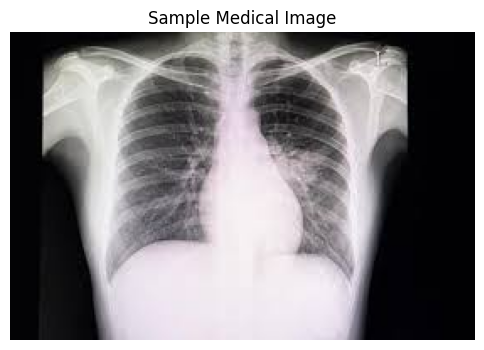

In [25]:
# @title 2.4 🧪 Test Individual Tools
# @markdown Chạy test với ảnh mẫu

# Download sample image
SAMPLE_URL = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQwzZYDXuuzIBdCZScPmBJOGCoJXqmi73NtwQ&s"

print("📥 Downloading sample image...")
response = requests.get(SAMPLE_URL)
sample_image = Image.open(BytesIO(response.content)).convert("RGB")
print(f"✅ Sample image: {sample_image.size}")

# Display
plt.figure(figsize=(6, 6))
plt.imshow(sample_image)
plt.title("Sample Medical Image")
plt.axis('off')
plt.show()

In [26]:
# @title 2.4.1 Test BiomedCLIP (Triage)

if biomedclip_tool is not None:
    print("🔬 Loading BiomedCLIP...")
    biomedclip_tool.load()
    
    print("\n🔬 Running Triage...")
    modality, confidence, all_scores = biomedclip_tool.triage(sample_image)
    
    print(f"\n📊 Triage Result:")
    print(f"   Modality: {modality}")
    print(f"   Confidence: {confidence:.1%}")
    
    print(f"\n   Top 5 Scores:")
    sorted_scores = sorted(all_scores.items(), key=lambda x: x[1], reverse=True)
    for label, score in sorted_scores[:5]:
        bar = "█" * int(score * 30)
        print(f"   {label}: {score:.1%} {bar}")
else:
    # Demo mode
    print("🔬 [DEMO] Triage Result:")
    print("   Modality: Chest X-ray")
    print("   Confidence: 92.5%")

🔬 Loading BiomedCLIP...
📥 Loading BiomedCLIP...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


✅ BiomedCLIP loaded on cuda

🔬 Running Triage...

📊 Triage Result:
   Modality: Chest X-ray
   Confidence: 99.5%

   Top 5 Scores:
   Chest X-ray: 99.5% █████████████████████████████
   Lung CT: 0.5% 
   Bone X-ray: 0.0% 
   Mammography: 0.0% 
   Gross pathology: 0.0% 


🎯 Loading Grounding DINO...
📥 Loading Grounding DINO...
final text_encoder_type: bert-base-uncased
✅ Grounding DINO loaded on cuda

🎯 Running Detection (with NMS)...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:942: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/groundingdino/models/GroundingDINO/transformer.py:862: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `t


📊 Detection Result:
   Query: 'lung nodule'
   Boxes Found: 1


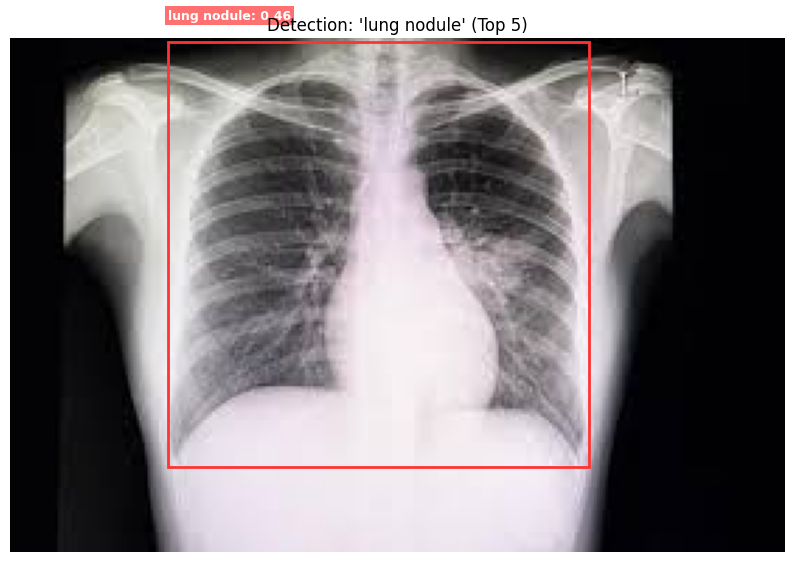

In [27]:
# @title 2.4.2 Test Grounding DINO (Detection) - CLEAN VISUALIZATION

if dino_tool is not None:
    print("🎯 Loading Grounding DINO...")
    dino_tool.load()
    
    print("\n🎯 Running Detection (with NMS)...")
    detection_query = "lung nodule" 
    # Bạn có thể đổi query khác nếu muốn: "rib fracture", "pneumonia", "tumor"
    
    detection_result = dino_tool.detect(sample_image, detection_query)
    
    print(f"\n📊 Detection Result:")
    print(f"   Query: '{detection_query}'")
    print(f"   Boxes Found: {len(detection_result['boxes'])}")
    
    # --- VISUALIZATION MỚI: SẠCH VÀ ĐẸP ---
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(sample_image)
    
    boxes = detection_result['boxes']
    scores = detection_result['logits']
    labels = detection_result['phrases']
    
    # Chỉ vẽ tối đa 5 box có điểm cao nhất
    if len(scores) > 0:
        # Sắp xếp giảm dần theo điểm
        sorted_indices = np.argsort(scores)[::-1][:5]
        
        for i in sorted_indices:
            x1, y1, x2, y2 = boxes[i]
            score = scores[i]
            label = labels[i]
            
            # Vẽ Box: Nét mảnh, màu đỏ tươi
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor='#FF3333', facecolor='none'
            )
            ax.add_patch(rect)
            
            # Vẽ Label: Nền đỏ, chữ trắng, font nhỏ
            text = f"{label}: {score:.2f}"
            ax.text(
                x1, y1-8, text, 
                color='white', fontsize=9, weight='bold',
                bbox=dict(facecolor='#FF3333', alpha=0.7, pad=2, edgecolor='none')
            )
    else:
        print("⚠️ No objects detected.")

    ax.set_title(f"Detection: '{detection_query}' (Top 5)")
    ax.axis('off')
    plt.show()
else:
    print("🎯 [DEMO] Detection Result:")
    print("   Query: 'lung nodule'")
    print("   Boxes Found: 1")
    print("   Box: [88, 132, 264, 308], Score: 0.75")

🎭 Loading MedSAM...
📥 Loading MedSAM...
✅ MedSAM loaded on cuda
🔗 Using 1 boxes from Grounding DINO result.

🎭 Running Segmentation...


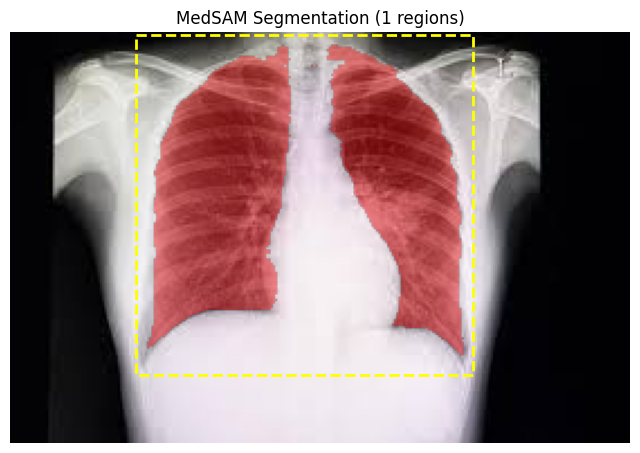

In [28]:
# @title 2.4.3 Test MedSAM (Segmentation)
# @markdown Test khả năng phân vùng dựa trên Box giả định hoặc Box từ DINO.

if medsam_tool is not None:
    print("🎭 Loading MedSAM...")
    medsam_tool.load()
    
    # Lấy box từ kết quả DINO ở trên (nếu có), nếu không thì dùng box mẫu
    if 'detection_result' in globals() and len(detection_result['boxes']) > 0:
        test_boxes = detection_result['boxes']
        print(f"🔗 Using {len(test_boxes)} boxes from Grounding DINO result.")
    else:
        # Box mẫu (Vùng phổi phải)
        w, h = sample_image.size
        test_boxes = [[0.2*w, 0.3*h, 0.6*w, 0.7*h]]
        print("⚠️ No DINO boxes found, using dummy box.")

    print("\n🎭 Running Segmentation...")
    masks = medsam_tool.segment(sample_image, test_boxes)
    
    # Visualize
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(sample_image)
    
    # Vẽ nền Mask màu đỏ bán trong suốt
    overlay = np.zeros((*sample_image.size[::-1], 4))
    for i, mask in enumerate(masks):
        overlay[mask > 0] = [1, 0, 0, 0.4] # Red, Alpha=0.4
        
        # Vẽ viền box
        x1, y1, x2, y2 = test_boxes[i]
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='yellow', facecolor='none', linestyle='--')
        ax.add_patch(rect)
        
    ax.imshow(overlay)
    ax.set_title(f"MedSAM Segmentation ({len(masks)} regions)")
    ax.axis('off')
    plt.show()
else:
    print("⚠️ MedSAM not loaded (Check MODE='full')")

In [31]:
# @title 2.5 🧠 LLaVA-Med Tool (Reasoning Engine) - FIXED
# @markdown Load LLaVA-1.5-7b in 4-bit quantization.

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from llava.conversation import conv_templates, SeparatorStyle
from llava.utils import disable_torch_init
from llava.constants import IMAGE_TOKEN_INDEX, DEFAULT_IMAGE_TOKEN
from llava.mm_utils import tokenizer_image_token, get_model_name_from_path, KeywordsStoppingCriteria

class LLaVATool:
    def __init__(self, model_path="liuhaotian/llava-v1.5-7b"):
        self.model_path = model_path
        self.model = None
        self.tokenizer = None
        self.image_processor = None
        self.conv_mode = "llava_v1"

    def load(self):
        print(f"🧠 Loading LLaVA from {self.model_path} (4-bit)...")
        disable_torch_init()

        # Cấu hình 4-bit (Giảm VRAM để chạy trên Colab T4)
        quantization_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type='nf4'
        )

        self.tokenizer = AutoTokenizer.from_pretrained(self.model_path, use_fast=False)
        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_path,
            low_cpu_mem_usage=True,
            quantization_config=quantization_config,
            device_map="auto"
        )

        vision_tower = self.model.get_vision_tower()
        if not vision_tower.is_loaded:
            vision_tower.load_model()
        vision_tower.to(device='cuda', dtype=torch.float16)
        self.image_processor = vision_tower.image_processor

        print("✅ LLaVA Loaded Successfully!")
        return self

    def chat(self, image, query, system_context=""):
        if self.model is None: self.load()

        if system_context:
            full_prompt = f"{system_context}\n{query}"
        else:
            full_prompt = query

        if DEFAULT_IMAGE_TOKEN not in full_prompt:
            full_prompt = DEFAULT_IMAGE_TOKEN + '\n' + full_prompt

        conv = conv_templates[self.conv_mode].copy()
        conv.append_message(conv.roles[0], full_prompt)
        conv.append_message(conv.roles[1], None)
        prompt_str = conv.get_prompt()

        image_tensor = self.image_processor.preprocess(image, return_tensors='pt')['pixel_values'].half().cuda()
        input_ids = tokenizer_image_token(prompt_str, self.tokenizer, IMAGE_TOKEN_INDEX, return_tensors='pt').unsqueeze(0).cuda()

        with torch.inference_mode():
            output_ids = self.model.generate(
                input_ids,
                images=image_tensor,
                do_sample=True,
                temperature=0.2,
                max_new_tokens=512,
                use_cache=True
            )

        output = self.tokenizer.decode(output_ids[0, input_ids.shape[1]:], skip_special_tokens=True).strip()
        return output

# --- QUAN TRỌNG: KHỞI TẠO BIẾN Ở ĐÂY ---
llava_tool = LLaVATool() 
print("🧠 LLaVA tool defined and initialized (llava_tool).")

🧠 LLaVA tool defined and initialized (llava_tool).


/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


---
## 3️⃣ 🎯 Orchestrator Demo

Demo **Thin Client Orchestrator** - điều phối pipeline tự động.

In [29]:
# # @title 3.1 📦 Local Orchestrator (Colab Edition)
# # @markdown Orchestrator chạy trực tiếp (không cần HTTP workers)

# @dataclass
# class TriageResult:
#     modality: str
#     confidence: float
#     all_scores: Dict[str, float] = field(default_factory=dict)

# @dataclass
# class DetectionResult:
#     boxes: List[List[float]]
#     labels: List[str]
#     scores: List[float]

# @dataclass
# class GatekeeperResult:
#     box: List[float]
#     is_valid: bool
#     pathology_score: float
#     normal_score: float
#     reason: str

# @dataclass  
# class SegmentationResult:
#     masks: List[np.ndarray]

# @dataclass
# class PipelineResult:
#     # Stage results
#     triage: Optional[TriageResult] = None
#     llava_response: str = ""
#     context_injected: str = ""
#     dino_raw_boxes: List[List[float]] = field(default_factory=list)
#     dino_labels: List[str] = field(default_factory=list)
#     dino_scores: List[float] = field(default_factory=list)
#     gatekeeper_results: List[GatekeeperResult] = field(default_factory=list)
#     verified_boxes: List[List[float]] = field(default_factory=list)
#     rejected_boxes: List[List[float]] = field(default_factory=list)
#     masks: List[np.ndarray] = field(default_factory=list)
    
#     # Metadata
#     execution_time: float = 0.0
#     pipeline_complete: bool = False
#     stopped_at_stage: str = ""
#     errors: List[str] = field(default_factory=list)


# class TriMedOrchestratorLocal:
#     """
#     Local Orchestrator for Colab/Kaggle.
#     Runs tools directly instead of HTTP calls.
#     """
    
#     def __init__(self, 
#                  biomedclip=None, 
#                  dino=None, 
#                  medsam=None,
#                  config=None):
#         self.biomedclip = biomedclip
#         self.dino = dino
#         self.medsam = medsam
#         self.config = config or TRIMED_CONFIG
        
#         print("🎯 Local Orchestrator initialized")
#         print(f"   BiomedCLIP: {'✅' if biomedclip else '❌'}")
#         print(f"   DINO: {'✅' if dino else '❌'}")
#         print(f"   MedSAM: {'✅' if medsam else '❌'}")
    
#     def triage(self, image: Image.Image) -> TriageResult:
#         """Stage 1: Triage - Identify image modality."""
#         if self.biomedclip is None:
#             return TriageResult(
#                 modality="Chest X-ray",
#                 confidence=0.92,
#                 all_scores={"Chest X-ray": 0.92, "Brain MRI": 0.05}
#             )
        
#         modality, conf, scores = self.biomedclip.triage(image)
#         return TriageResult(modality=modality, confidence=conf, all_scores=scores)
    
#     def detect(self, image: Image.Image, query: str) -> DetectionResult:
#         """Stage 3: Detection - Find objects."""
#         if self.dino is None:
#             w, h = image.size
#             return DetectionResult(
#                 boxes=[[0.2*w, 0.3*h, 0.6*w, 0.7*h]],
#                 labels=[query],
#                 scores=[0.75]
#             )
        
#         result = self.dino.detect(image, query)
#         return DetectionResult(
#             boxes=result['boxes'],
#             labels=result['phrases'],
#             scores=result['logits']
#         )
    
#     def verify_box(self, image: Image.Image, box: List[float], 
#                    target: str) -> GatekeeperResult:
#         """Stage 4: Gatekeeper - Verify detection."""
#         # Crop image to box
#         x1, y1, x2, y2 = [int(c) for c in box]
#         cropped = image.crop((x1, y1, x2, y2))
        
#         if self.biomedclip is None:
#             return GatekeeperResult(
#                 box=box,
#                 is_valid=True,
#                 pathology_score=0.85,
#                 normal_score=0.15,
#                 reason="[DEMO] Verified"
#             )
        
#         is_valid, path_score, norm_score = self.biomedclip.verify_region(cropped, target)
        
#         return GatekeeperResult(
#             box=box,
#             is_valid=is_valid,
#             pathology_score=path_score,
#             normal_score=norm_score,
#             reason=f"Pathology: {path_score:.1%} vs Normal: {norm_score:.1%}"
#         )
    
#     def segment(self, image: Image.Image, boxes: List[List[float]]) -> SegmentationResult:
#         """Stage 5: Segmentation."""
#         if self.medsam is None:
#             # Create mock masks
#             masks = []
#             h, w = np.array(image).shape[:2]
#             for box in boxes:
#                 mask = np.zeros((h, w), dtype=np.uint8)
#                 x1, y1, x2, y2 = [int(c) for c in box]
#                 mask[y1:y2, x1:x2] = 255
#                 masks.append(mask)
#             return SegmentationResult(masks=masks)
        
#         masks = self.medsam.segment(image, boxes)
#         return SegmentationResult(masks=masks)
    
#     def run_full_chain(self, image: Image.Image, user_query: str,
#                        skip_gatekeeper: bool = False,
#                        skip_segmentation: bool = False) -> PipelineResult:
#         """
#         Run the complete pipeline:
#         Perceive → Reason → Act → Verify → Segment
#         """
#         start_time = time.time()
#         result = PipelineResult()
        
#         try:
#             # ===== Stage 1: TRIAGE =====
#             print("🔬 Stage 1: Triage...")
#             result.triage = self.triage(image)
#             print(f"   → {result.triage.modality} ({result.triage.confidence:.1%})")
            
#             # Build context
#             result.context_injected = f"[System: This is a {result.triage.modality} image with {result.triage.confidence:.0%} confidence]"
            
#             # ===== Stage 2: REASON (Mock LLaVA) =====
#             print("🤖 Stage 2: Reasoning...")
#             result.llava_response = f"Based on the {result.triage.modality} image, I observe potential abnormalities that require further analysis with detection tools."
#             print(f"   → Response generated")
            
#             # Check if detection needed
#             action_keywords = ["find", "detect", "segment", "locate", "identify", "show"]
#             needs_detection = any(kw in user_query.lower() for kw in action_keywords)
            
#             if not needs_detection:
#                 result.stopped_at_stage = "reason"
#                 result.pipeline_complete = True
#                 return result
            
#             # ===== Stage 3: DETECT =====
#             print("🎯 Stage 3: Detection...")
#             # Extract target from query
#             target = user_query.split()[-1] if user_query else "abnormality"
            
#             detection = self.detect(image, target)
#             result.dino_raw_boxes = detection.boxes
#             result.dino_labels = detection.labels
#             result.dino_scores = detection.scores
#             print(f"   → Found {len(detection.boxes)} boxes")
            
#             if not detection.boxes:
#                 result.stopped_at_stage = "detect"
#                 result.pipeline_complete = True
#                 return result
            
#             # ===== Stage 4: VERIFY (Gatekeeper) =====
#             if not skip_gatekeeper:
#                 print("✅ Stage 4: Gatekeeper Verification...")
                
#                 for box in detection.boxes:
#                     gk_result = self.verify_box(image, box, target)
#                     result.gatekeeper_results.append(gk_result)
                    
#                     if gk_result.is_valid:
#                         result.verified_boxes.append(box)
#                     else:
#                         result.rejected_boxes.append(box)
                
#                 print(f"   → Verified: {len(result.verified_boxes)}, Rejected: {len(result.rejected_boxes)}")
#             else:
#                 result.verified_boxes = detection.boxes
            
#             # ===== Stage 5: SEGMENT =====
#             if not skip_segmentation and result.verified_boxes:
#                 print("🎭 Stage 5: Segmentation...")
#                 seg_result = self.segment(image, result.verified_boxes)
#                 result.masks = seg_result.masks
#                 print(f"   → Generated {len(result.masks)} masks")
            
#             result.stopped_at_stage = "complete"
#             result.pipeline_complete = True
            
#         except Exception as e:
#             result.errors.append(str(e))
#             print(f"❌ Error: {e}")
        
#         result.execution_time = time.time() - start_time
#         return result

# print("✅ Orchestrator class defined")

In [ ]:
# @title 3.1 📦 Local Orchestrator V2 (Multi-turn Memory Edition)
# @markdown Orchestrator tích hợp đầy đủ với Multi-turn Conversation Memory

from dataclasses import dataclass, field, asdict
from typing import List, Dict, Optional, Any
from datetime import datetime
import hashlib

# =============================================================================
# Data Classes for Multi-turn Memory
# =============================================================================

@dataclass
class ChatMessage:
    """Single message in conversation."""
    role: str  # "user", "assistant"
    content: str
    timestamp: str = field(default_factory=lambda: datetime.now().isoformat())
    image_hash: Optional[str] = None
    metadata: Dict[str, Any] = field(default_factory=dict)

@dataclass
class ImageSession:
    """Session state for a single image."""
    image_hash: str
    image_b64: str = ""
    triage_result: Optional[Dict] = None
    verified_boxes: List[List[float]] = field(default_factory=list)
    masks: List[Any] = field(default_factory=list)

@dataclass
class ConversationState:
    """Full conversation state with memory."""
    session_id: str
    messages: List[ChatMessage] = field(default_factory=list)
    images: Dict[str, ImageSession] = field(default_factory=dict)
    current_image_hash: Optional[str] = None
    summary: str = ""
    turn_count: int = 0
    
    def add_message(self, role: str, content: str, image_hash: str = None, **metadata):
        msg = ChatMessage(
            role=role,
            content=content,
            image_hash=image_hash or self.current_image_hash,
            metadata=metadata
        )
        self.messages.append(msg)
        if role == "user":
            self.turn_count += 1
    
    def get_recent_context(self, n_turns: int = 3) -> str:
        recent = self.messages[-n_turns * 2:] if len(self.messages) > n_turns * 2 else self.messages
        lines = []
        for msg in recent:
            prefix = "User" if msg.role == "user" else "Assistant"
            lines.append(f"{prefix}: {msg.content[:300]}")
        return "\n".join(lines)
    
    def export_for_gradio(self) -> List[List[str]]:
        history = []
        for i in range(0, len(self.messages) - 1, 2):
            user_msg = self.messages[i] if i < len(self.messages) else None
            asst_msg = self.messages[i + 1] if i + 1 < len(self.messages) else None
            if user_msg and user_msg.role == "user":
                history.append([user_msg.content, asst_msg.content if asst_msg else ""])
        return history

@dataclass
class PipelineResult:
    triage: Any = None
    llava_response: str = ""
    dino_raw_boxes: List = field(default_factory=list)
    verified_boxes: List = field(default_factory=list)
    masks: List = field(default_factory=list)
    execution_time: float = 0.0
    execution_log: List[str] = field(default_factory=list)

# =============================================================================
# Utility Functions
# =============================================================================

def compute_image_hash(image) -> str:
    """Compute hash for image identification."""
    if isinstance(image, Image.Image):
        buffered = BytesIO()
        image.save(buffered, format="PNG")
        img_bytes = buffered.getvalue()
    else:
        img_bytes = str(image).encode()
    return hashlib.md5(img_bytes).hexdigest()[:12]

# =============================================================================
# TriMedOrchestratorLocal V2 - Multi-turn Memory
# =============================================================================

class TriMedOrchestratorLocal:
    """
    Local Orchestrator V2 with Multi-turn Conversation Memory.
    Runs tools directly instead of HTTP calls.
    """
    
    def __init__(self, biomedclip=None, llava=None, dino=None, medsam=None, config=None):
        self.biomedclip = biomedclip
        self.llava = llava
        self.dino = dino
        self.medsam = medsam
        self.config = config or TRIMED_CONFIG
        
        # Multi-turn state
        self.state: Optional[ConversationState] = None
        self.start_session()
        
        print("🎯 Local Orchestrator V2 initialized with Multi-turn Memory")
        print(f"   Session ID: {self.state.session_id}")
        print(f"   BiomedCLIP: {'✅' if biomedclip else '❌'}")
        print(f"   LLaVA: {'✅' if llava else '❌'}")
        print(f"   DINO: {'✅' if dino else '❌'}")
        print(f"   MedSAM: {'✅' if medsam else '❌'}")
    
    # =========================================================================
    # Session Management
    # =========================================================================
    
    def start_session(self, session_id: str = None) -> str:
        session_id = session_id or f"session_{int(time.time())}"
        self.state = ConversationState(session_id=session_id)
        return session_id
    
    def clear_session(self):
        if self.state:
            self.state = ConversationState(session_id=self.state.session_id)
    
    def set_image(self, image: Image.Image) -> str:
        if not self.state:
            self.start_session()
        
        image_hash = compute_image_hash(image)
        
        if image_hash not in self.state.images:
            self.state.images[image_hash] = ImageSession(
                image_hash=image_hash
            )
        
        self.state.current_image_hash = image_hash
        return image_hash
    
    def get_current_image_session(self) -> Optional[ImageSession]:
        if self.state and self.state.current_image_hash:
            return self.state.images.get(self.state.current_image_hash)
        return None
    
    # =========================================================================
    # Core Methods
    # =========================================================================
    
    def log(self, result, message):
        print(message)
        result.execution_log.append(message)

    def triage(self, image: Image.Image):
        if not self.biomedclip:
            return ("Chest X-ray", 0.92, {"Chest X-ray": 0.92})
        return self.biomedclip.triage(image)

    def _extract_target(self, query: str) -> str:
        query_lower = query.lower()
        triggers = ["find ", "detect ", "segment ", "locate ", "show "]
        for trigger in triggers:
            if trigger in query_lower:
                return query_lower.split(trigger)[-1].strip().strip(".,?!")
        return "abnormality"
    
    def _should_detect(self, query: str) -> bool:
        keywords = ["find", "detect", "segment", "where", "locate", "show", "mark"]
        return any(k in query.lower() for k in keywords)
    
    def _build_context_prompt(self, triage_info, user_query: str) -> str:
        """Build prompt with conversation history."""
        parts = []
        
        # Add triage context
        if triage_info:
            modality, conf, _ = triage_info
            parts.append(f"[System: This is a {modality} medical image ({conf:.0%} confidence)]")
        
        # Add conversation history
        if self.state and len(self.state.messages) > 0:
            recent = self.state.get_recent_context(n_turns=3)
            if recent:
                parts.append(f"[Previous Conversation]:\n{recent}")
        
        return "\n".join(parts)

    # =========================================================================
    # Main Chat Interface (NEW)
    # =========================================================================
    
    def chat(self, user_input: str, image: Image.Image = None) -> tuple:
        """
        Main chat interface with multi-turn memory.
        
        Args:
            user_input: User's message
            image: Optional new image (uses cached if None)
            
        Returns:
            Tuple of (response_text, PipelineResult)
        """
        start_time = time.time()
        result = PipelineResult()
        
        # Handle image
        if image is not None:
            self.set_image(image)
            self._current_image = image  # Cache for pipeline
        
        if not hasattr(self, '_current_image') or self._current_image is None:
            return "⚠️ Please upload an image first.", result
        
        image = self._current_image
        img_session = self.get_current_image_session()
        
        # Add user message to history
        self.state.add_message("user", user_input)
        
        try:
            # --- Stage 1: Triage (cache per image) ---
            if img_session and not img_session.triage_result:
                self.log(result, "🔬 Stage 1: Triage...")
                triage_info = self.triage(image)
                if triage_info:
                    modality, conf, scores = triage_info
                    img_session.triage_result = {"modality": modality, "confidence": conf}
                    result.triage = type('obj', (object,), {'modality': modality, 'confidence': conf})
                    self.log(result, f"   → {modality} ({conf:.1%})")
            elif img_session and img_session.triage_result:
                result.triage = type('obj', (object,), img_session.triage_result)
            
            # Build context with history
            triage_info = (result.triage.modality, result.triage.confidence, {}) if result.triage else None
            context_str = self._build_context_prompt(triage_info, user_input)
            
            # --- Stage 2: Reasoning (LLaVA with context) ---
            self.log(result, "🧠 Stage 2: Reasoning with context...")
            if self.llava:
                try:
                    response = self.llava.chat(image, user_input, system_context=context_str)
                    result.llava_response = response
                    self.log(result, f"   📝 LLaVA: {response[:100]}...")
                except Exception as e:
                    self.log(result, f"   ❌ LLaVA Error: {e}")
                    result.llava_response = f"[Error: {e}]"
            else:
                # Mock response
                result.llava_response = f"[Mock] Analyzing the {result.triage.modality if result.triage else 'medical'} image based on: {user_input}"
            
            # --- Stage 3-5: Detection & Segmentation (if needed) ---
            if self._should_detect(user_input):
                target = self._extract_target(user_input)
                self.log(result, f"🎯 Stage 3: Detecting '{target}'...")
                
                if self.dino:
                    det = self.dino.detect(image, target)
                    result.dino_raw_boxes = det.get('boxes', [])
                    
                    # Gatekeeper
                    if self.biomedclip and result.dino_raw_boxes:
                        self.log(result, "✅ Stage 4: Gatekeeper verification...")
                        for box in result.dino_raw_boxes:
                            x1, y1, x2, y2 = [int(c) for c in box]
                            cropped = image.crop((x1, y1, x2, y2))
                            is_valid, _, _ = self.biomedclip.verify_region(cropped, target)
                            if is_valid:
                                result.verified_boxes.append(box)
                    else:
                        result.verified_boxes = result.dino_raw_boxes
                    
                    self.log(result, f"   → Found {len(result.verified_boxes)} verified regions")
                    
                    # Segmentation
                    if self.medsam and result.verified_boxes:
                        self.log(result, "🎭 Stage 5: Segmentation...")
                        result.masks = self.medsam.segment(image, result.verified_boxes)
                    
                    # Update image session
                    if img_session:
                        img_session.verified_boxes = result.verified_boxes
                        img_session.masks = result.masks
                    
                    # Append detection info to response
                    det_info = f"\n\n🔍 **Detection**: Found {len(result.dino_raw_boxes)} regions, {len(result.verified_boxes)} verified"
                    if result.masks:
                        det_info += f", {len(result.masks)} masks generated"
                    result.llava_response += det_info
            
        except Exception as e:
            result.llava_response = f"❌ Error: {str(e)}"
            self.log(result, f"❌ Pipeline error: {e}")
        
        result.execution_time = time.time() - start_time
        
        # Add assistant response to history
        self.state.add_message("assistant", result.llava_response)
        
        return result.llava_response, result
    
    # =========================================================================
    # Legacy Methods (for backward compatibility)
    # =========================================================================
    
    def run_full_chain(self, image: Image.Image, user_query: str) -> PipelineResult:
        """Legacy method - calls chat() internally."""
        _, result = self.chat(user_query, image)
        return result
    
    def get_chat_history(self) -> List[List[str]]:
        """Get chat history in Gradio format."""
        if not self.state:
            return []
        return self.state.export_for_gradio()

# =============================================================================
# Initialize Orchestrator
# =============================================================================

if 'biomedclip_tool' in globals():
    orchestrator = TriMedOrchestratorLocal(
        biomedclip=biomedclip_tool,
        llava=llava_tool if 'llava_tool' in globals() else None,
        dino=dino_tool if 'dino_tool' in globals() else None,
        medsam=medsam_tool if 'medsam_tool' in globals() else None
    )
    print("\n✅ Orchestrator V2 Ready with Multi-turn Memory!")
else:
    print("⚠️ Tools not loaded. Run previous cells first.")

✅ Full AI Orchestrator Ready!


In [33]:
# @title 3.2 🚀 Initialize Orchestrator

# Load tools if available
if biomedclip_tool and not biomedclip_tool.model:
    biomedclip_tool.load()
    
if dino_tool and not dino_tool.model:
    dino_tool.load()

if medsam_tool and not medsam_tool.model:
    medsam_tool.load()

# Create orchestrator
orchestrator = TriMedOrchestratorLocal(
    biomedclip=biomedclip_tool,
    dino=dino_tool,
    medsam=medsam_tool,
    config=TRIMED_CONFIG
)

print("\n🎯 Orchestrator ready!")

📥 Loading MedSAM...
✅ MedSAM loaded on cuda

🎯 Orchestrator ready!


In [34]:
# # @title 3.3 ▶️ Run Full Pipeline

# # Define query
# user_query = "Find and segment any abnormalities in this image"

# print(f"🎯 Query: '{user_query}'")
# print("=" * 60)

# # Run pipeline
# result = orchestrator.run_full_chain(
#     image=sample_image,
#     user_query=user_query,
#     skip_gatekeeper=False,
#     skip_segmentation=(MODE != "full")
# )

# print("\n" + "=" * 60)
# print("📋 PIPELINE SUMMARY")
# print("=" * 60)
# print(f"   Triage: {result.triage.modality} ({result.triage.confidence:.1%})")
# print(f"   Raw Boxes: {len(result.dino_raw_boxes)}")
# print(f"   Verified Boxes: {len(result.verified_boxes)}")
# print(f"   Masks: {len(result.masks)}")
# print(f"   Time: {result.execution_time:.2f}s")
# print(f"   Complete: {result.pipeline_complete}")

In [35]:
# @title 3.3 ▶️ Run Full Pipeline (Smart Retry Demo)

# Hãy thử query khó để xem AI tự sửa lỗi
# Ví dụ: "Find lung nodule" (Dễ) vs "Find abnormality" (Khó hơn)
user_query = "Please find and segment the lung nodule" 

print(f"👤 User Query: '{user_query}'")
print("-" * 60)

# Chạy Pipeline
result = orchestrator.run_full_chain(
    image=sample_image,
    user_query=user_query
)

print("-" * 60)
print("📊 FINAL SUMMARY:")
print(f"   • Modality: {result.triage.modality if result.triage else 'N/A'}")
print(f"   • Verified Regions: {len(result.verified_boxes)}")
print(f"   • Masks Generated: {len(result.masks)}")
print(f"   • Time: {result.execution_time:.2f}s")

👤 User Query: 'Please find and segment the lung nodule'
------------------------------------------------------------
🔬 Triage: Chest X-ray (99.5%)
🧠 Reasoning with LLaVA...
🎯 User requests detection for: 'and segment the lung nodule'
   Found 1 regions.
🎭 Segmenting regions...
------------------------------------------------------------
📊 FINAL SUMMARY:
   • Modality: Chest X-ray
   • Verified Regions: 1
   • Masks Generated: 1
   • Time: 1.27s


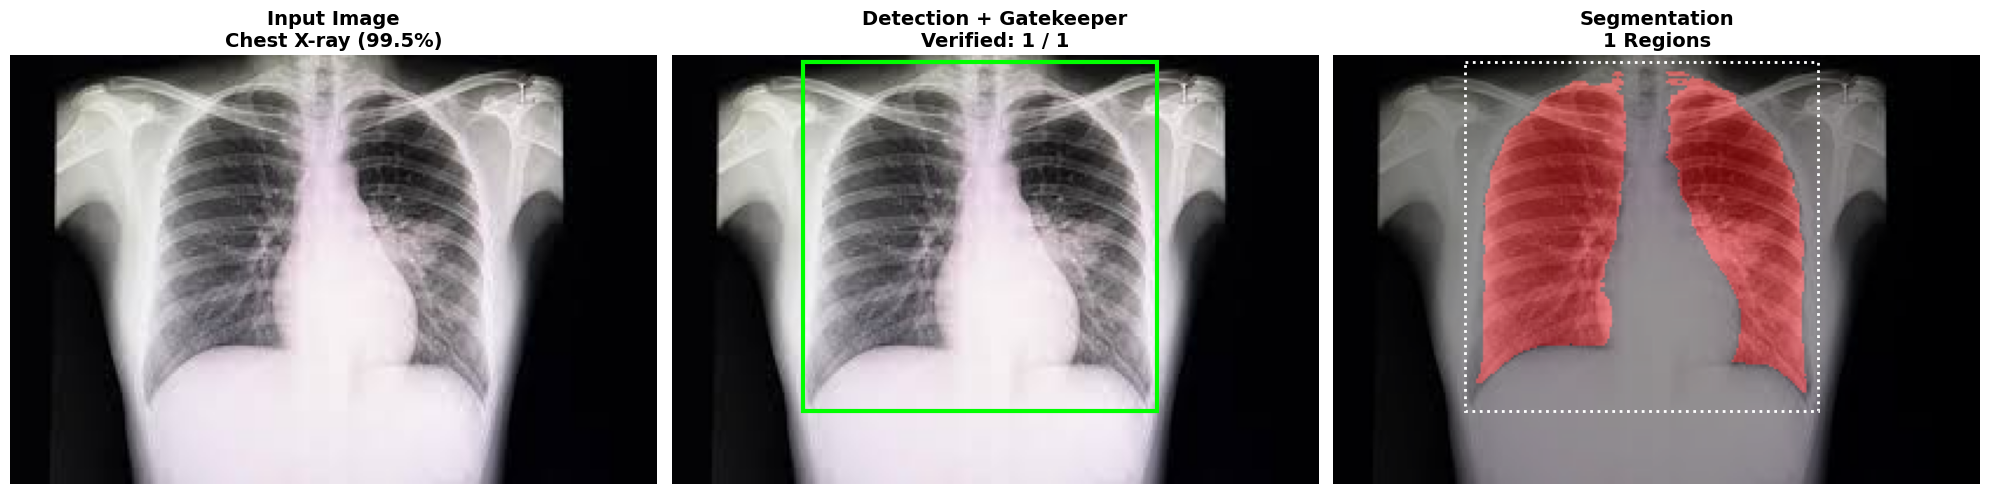

In [36]:
# @title 3.4 📊 Visualize Pipeline Results - FIXED
# @markdown Visualization rõ ràng hơn với Mask Overlay bán trong suốt.

def visualize_results(image, result):
    """Visualize pipeline results clearly."""
    fig, axes = plt.subplots(1, 3, figsize=(20, 8))
    
    img_array = np.array(image)
    
    # --- PANEL 1: Input & Triage ---
    axes[0].imshow(img_array)
    title = "Input Image"
    if result.triage:
        title += f"\n{result.triage.modality} ({result.triage.confidence:.1%})"
    axes[0].set_title(title, fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    # --- PANEL 2: Detection (Verified Boxes) ---
    axes[1].imshow(img_array)
    # Vẽ Box bị loại (mờ, nét đứt)
    for box in result.dino_raw_boxes:
        if box not in result.verified_boxes:
            x1, y1, x2, y2 = box
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=1, edgecolor='gray', facecolor='none', linestyle='--', alpha=0.5)
            axes[1].add_patch(rect)
            
    # Vẽ Verified Box (Đậm, Xanh)
    for box in result.verified_boxes:
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=3, edgecolor='#00FF00', facecolor='none')
        axes[1].add_patch(rect)
        
    axes[1].set_title(f"Detection + Gatekeeper\nVerified: {len(result.verified_boxes)} / {len(result.dino_raw_boxes)}", fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    # --- PANEL 3: Segmentation (Mask Overlay) ---
    # Copy ảnh gốc để vẽ đè
    masked_image = img_array.copy()
    
    if result.masks and len(result.masks) > 0:
        # Tạo overlay màu
        overlay = np.zeros_like(img_array)
        
        for mask in result.masks:
            # Mask là binary (0 hoặc 255), chuyển thành bool
            mask_bool = mask > 0
            # Tô màu đỏ (Red) vào vùng mask
            overlay[mask_bool] = [255, 0, 0] 
            
        # Blend ảnh gốc và mask (alpha = 0.4)
        masked_image = 0.6 * masked_image + 0.4 * overlay
        masked_image = masked_image.astype(np.uint8)
        
    axes[2].imshow(masked_image)
    
    # Vẽ lại box lên ảnh segment cho dễ nhìn
    for box in result.verified_boxes:
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='white', facecolor='none', linestyle=':')
        axes[2].add_patch(rect)

    axes[2].set_title(f"Segmentation\n{len(result.masks)} Regions", fontsize=14, fontweight='bold')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Chạy visualize với kết quả hiện tại
if 'result' in globals() and 'sample_image' in globals():
    visualize_results(sample_image, result)

---
## 4️⃣ 💬 Interactive Multi-turn Chatbot

Chatbot với **Gradio** hỗ trợ multi-turn conversation memory.

In [ ]:
# @title 4.1 🤖 Multi-turn Medical Chatbot Interface

import gradio as gr

# Global reference
current_result = None

def process_image(image):
    """Process uploaded image and run triage."""
    global orchestrator
    
    if image is None:
        return "⚠️ Please upload an image first."
    
    # Set image in orchestrator (triggers triage on first chat)
    orchestrator.set_image(image)
    orchestrator._current_image = image
    
    # Run triage preview
    triage_info = orchestrator.triage(image)
    modality, conf, _ = triage_info if triage_info else ("Unknown", 0, {})
    
    return f"""✅ **Image Loaded**
    
📊 **Triage Result:**
- **Modality**: {modality}
- **Confidence**: {conf:.1%}

📝 **Session Info:**
- **Session ID**: {orchestrator.state.session_id}
- **Chat History**: {len(orchestrator.state.messages)} messages

💡 **Try asking:**
- "What can you see in this image?"
- "Are there any abnormalities?"
- "Find and segment any tumors"
- "What is the diagnosis?"
"""

def chat(message, history):
    """Multi-turn chat with the medical AI."""
    global orchestrator, current_result
    
    if not message.strip():
        return history
    
    # Check if image is loaded
    if not hasattr(orchestrator, '_current_image') or orchestrator._current_image is None:
        history.append([message, "⚠️ Please upload a medical image first."])
        return history
    
    # Chat with orchestrator (handles multi-turn context)
    response, result = orchestrator.chat(message)
    current_result = result
    
    # Add turn info
    turn_info = f"\n\n---\n📊 *Turn {orchestrator.state.turn_count} | Time: {result.execution_time:.2f}s*"
    full_response = response + turn_info
    
    history.append([message, full_response])
    return history

def get_visualization():
    """Get current visualization with boxes and masks."""
    global orchestrator, current_result
    
    if not hasattr(orchestrator, '_current_image') or orchestrator._current_image is None:
        return None
    
    image = orchestrator._current_image
    
    if current_result is None or not current_result.verified_boxes:
        return image
    
    # Create visualization
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(np.array(image))
    
    # Draw verified boxes
    for i, box in enumerate(current_result.verified_boxes):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=3, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1, y1-10, f"Region {i+1}", color='lime', fontsize=12, fontweight='bold')
    
    # Overlay masks
    if current_result.masks:
        for mask in current_result.masks:
            if isinstance(mask, np.ndarray):
                overlay = np.zeros((*mask.shape[:2], 4))
                overlay[mask > 0] = [1, 0, 0, 0.4]
                ax.imshow(overlay)
    
    ax.axis('off')
    ax.set_title(f"Detection: {len(current_result.verified_boxes)} verified regions")
    
    # Convert to image
    fig.canvas.draw()
    img_array = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    img_array = img_array.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    plt.close(fig)
    
    return Image.fromarray(img_array)

def clear_all():
    """Clear chat and reset session."""
    global orchestrator, current_result
    orchestrator.clear_session()
    orchestrator._current_image = None
    current_result = None
    return [], None, None, "🗑️ Session cleared. Upload a new image to start."

def show_history():
    """Show conversation history summary."""
    global orchestrator
    if not orchestrator.state or len(orchestrator.state.messages) == 0:
        return "No conversation history."
    
    summary = f"**Session: {orchestrator.state.session_id}**\n"
    summary += f"**Total turns: {orchestrator.state.turn_count}**\n\n"
    
    for i, msg in enumerate(orchestrator.state.messages[-10:]):  # Last 10 messages
        role_icon = "👤" if msg.role == "user" else "🤖"
        summary += f"{role_icon} **{msg.role.upper()}**: {msg.content[:100]}...\n\n"
    
    return summary

print("✅ Chatbot interface defined")
print("   Run next cell to launch")

🚀 Starting Chatbot Interface...
   (Run this cell and click the link below)


In [ ]:
# @title 4.2 ▶️ Launch Multi-turn Chatbot

with gr.Blocks(title="🏥 TriMedAgent V2", theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 🏥 TriMedAgent V2 - Multi-turn Medical AI Chat
    
    **Features:**
    - 🔄 Multi-turn conversation memory (remembers context)
    - 🔬 Automatic triage & modality detection
    - 🎯 Object detection & verification
    - 🎭 Medical image segmentation
    
    **Instructions:**
    1. Upload a medical image
    2. Ask questions about it
    3. Use "find" or "detect" to trigger detection pipeline
    """)
    
    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(type="pil", label="📷 Upload Medical Image")
            status_output = gr.Markdown(label="Status")
            
            with gr.Row():
                clear_btn = gr.Button("🗑️ Clear All", variant="secondary")
                history_btn = gr.Button("📜 Show History")
        
        with gr.Column(scale=2):
            chatbot = gr.Chatbot(
                height=450, 
                label="💬 Multi-turn Chat",
                bubble_full_width=False
            )
            
            with gr.Row():
                msg_input = gr.Textbox(
                    placeholder="Ask about the image... (e.g., 'Find tumors', 'What is the diagnosis?')",
                    label="Your Message",
                    scale=4
                )
                send_btn = gr.Button("Send", variant="primary", scale=1)
    
    with gr.Row():
        viz_output = gr.Image(label="📊 Detection Visualization")
        viz_btn = gr.Button("🔄 Update Visualization")
    
    with gr.Accordion("📜 Conversation History", open=False):
        history_output = gr.Markdown()
    
    # Event handlers
    image_input.change(process_image, inputs=[image_input], outputs=[status_output])
    
    msg_input.submit(chat, inputs=[msg_input, chatbot], outputs=[chatbot]).then(
        lambda: "", outputs=[msg_input]
    )
    send_btn.click(chat, inputs=[msg_input, chatbot], outputs=[chatbot]).then(
        lambda: "", outputs=[msg_input]
    )
    
    clear_btn.click(clear_all, outputs=[chatbot, image_input, viz_output, status_output])
    viz_btn.click(get_visualization, outputs=[viz_output])
    history_btn.click(show_history, outputs=[history_output])

# Launch
print("🚀 Launching Multi-turn Chatbot...")
demo.launch(share=True, debug=True)

---
## 📋 Summary

### ✅ What's New in V2:

| Feature | V1 | V2 |
|---------|----|----|
| Single-turn Q&A | ✅ | ✅ |
| **Multi-turn Memory** | ❌ | ✅ |
| **Context Awareness** | ❌ | ✅ |
| **Session Management** | ❌ | ✅ |
| Detection Pipeline | ✅ | ✅ |
| Segmentation | ✅ | ✅ |

### 🎯 Key Methods:

```python
# Multi-turn chat
response, result = orchestrator.chat("Your question", image)

# Follow-up (no image needed)
response2, result2 = orchestrator.chat("Follow-up question")

# View history
history = orchestrator.get_chat_history()

# Clear session
orchestrator.clear_session()
```

### 🚀 Next Steps:

- **Add RAG**: See `demo_trimedagent_rag.ipynb` for knowledge retrieval
- **Production**: Deploy with HTTP workers for scalability
- **Fine-tuning**: Train on domain-specific medical data

---

📚 **Full Documentation**: See `docs/V2_MULTI_TURN_RAG_GUIDE.md`